Baseline parameters
-------------------
D_c       = 1.0000
kappa     = 5.0000
alpha0    = 2.0000
Da0       = 0.5000
PeC       = 0.5000
M0        = 2.0000
Dphi      = 2.0000
chi0 MIPS = 1.0000
chi0 KS   = 1.0000
k         = 0.1000
mu_h'(phi0) = -1.115408


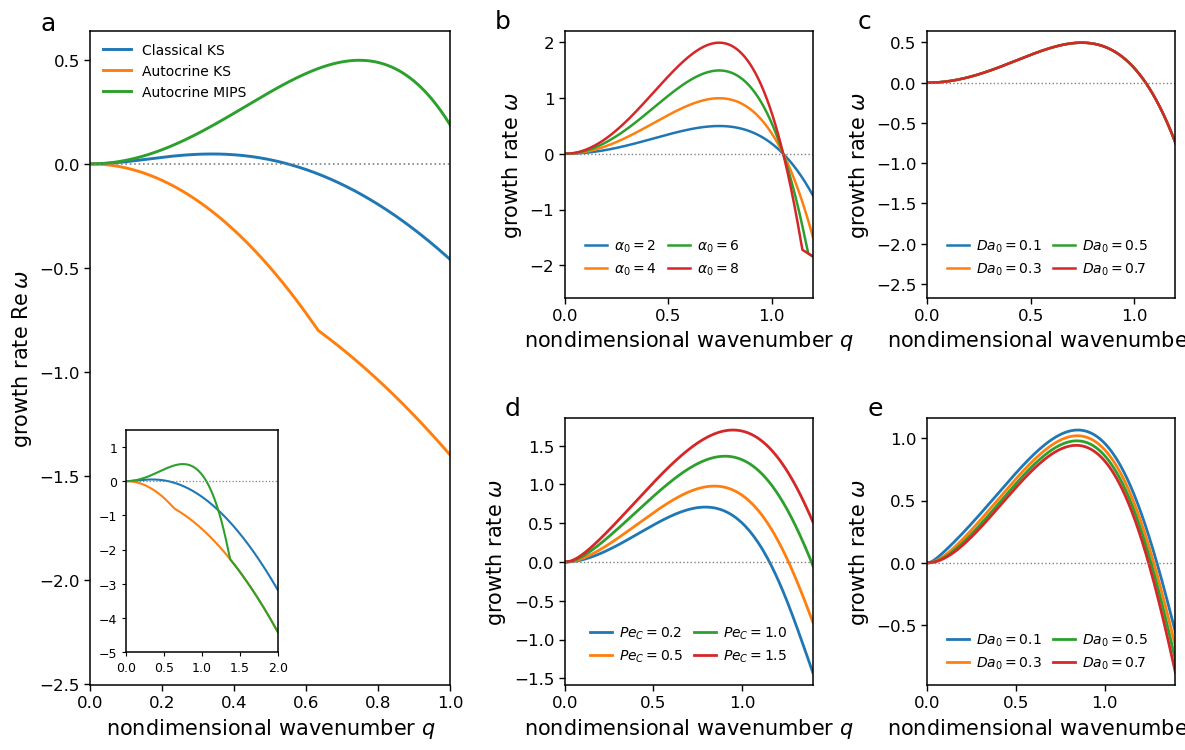

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Plot style
plt.rcParams.update({"font.size": 13, "axes.labelsize": 15, "legend.fontsize": 10, "xtick.labelsize": 12, "ytick.labelsize": 12, 
                     "lines.linewidth": 2.1, "axes.linewidth": 1.1, "xtick.major.width": 1.0, "ytick.major.width": 1.0, 
                     "xtick.major.size": 4.0, "ytick.major.size": 4.0,})
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Shared model parameters
phi0 = 0.8
phi_m = 0.9
Pe_R = 1e-3

# These are used to define the nondimensional ratios
D_c = 1.0
kappa = 5.0

# Shared nondimensional baseline
alpha0_base = 2.0
Da0_base = 0.5
PeC_base = 0.5

M0_base = alpha0_base * D_c
Dphi_base = alpha0_base * D_c
chi0_mips_base = PeC_base * M0_base
chi0_ks_base = PeC_base * Dphi_base
k_base = Da0_base * D_c / kappa
print("Baseline parameters")
print("-------------------")
print(f"D_c       = {D_c:.4f}")
print(f"kappa     = {kappa:.4f}")
print(f"alpha0    = {alpha0_base:.4f}")
print(f"Da0       = {Da0_base:.4f}")
print(f"PeC       = {PeC_base:.4f}")
print(f"M0        = {M0_base:.4f}")
print(f"Dphi      = {Dphi_base:.4f}")
print(f"chi0 MIPS = {chi0_mips_base:.4f}")
print(f"chi0 KS   = {chi0_ks_base:.4f}")
print(f"k         = {k_base:.4f}")

# Bulk chemical-potential slope
def dmu_h(phi):
    return (1 / phi - 2 - 0.6 * phi - (4 / np.pi) * Pe_R * phi_m * (phi - 2 * phi_m) / (phi - phi_m) ** 2)

dmu = dmu_h(phi0)
print(f"mu_h'(phi0) = {dmu:.6f}")

# Panel-label helper
def add_panel_label(ax, label, x=-0.16, y=1.03):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=18, fontweight="normal", va="top", ha="left", clip_on=False)

# General eigenvalue helper Linear matrix
def coupled_eigenvalues(A, B, C, D):
    discriminant = (A - D) ** 2 + 4 * B * C
    root = np.sqrt(discriminant.astype(complex))
    omega_plus = 0.5 * (-(A + D) + root)
    omega_minus = 0.5 * (-(A + D) - root)
    return omega_plus, omega_minus

# Growth-rate scale conversion KS or MIPS nondimensionalisation uses the cell transport time. 
#To compare all panels using one fixed chemical-diffusion time scale: omega_Dc = alpha0 * omega_native
def to_common_growth_scale(omega_native, alpha0):
    return alpha0 * omega_native

# 1. Classical Keller-Segel 
def omega_classical_ks(q, alpha0, Da0, PeC):
    A = q**2
    B = PeC * phi0 * q**2
    C = np.ones_like(q)
    D = (q**2 + Da0) / alpha0
    omega_plus_native, omega_minus_native = coupled_eigenvalues(A, B, C, D)
    omega_plus = to_common_growth_scale(omega_plus_native, alpha0)
    omega_minus = to_common_growth_scale(omega_minus_native, alpha0)
    return omega_plus, omega_minus

# 2. Autocrine Keller-Segel 
def omega_autocrine_ks(q, alpha0, Da0):
    omega_phi_native = -q**2
    omega_c_native = -(q**2 + Da0 * phi0) / alpha0
    omega_plus_native = np.maximum(omega_phi_native, omega_c_native)
    omega_minus_native = np.minimum(omega_phi_native, omega_c_native)
    omega_plus = to_common_growth_scale(omega_plus_native, alpha0)
    omega_minus = to_common_growth_scale(omega_minus_native, alpha0)
    return omega_plus, omega_minus

# 3. Autocrine MIPS 
def omega_autocrine_mips(q, alpha0, Da0):
    omega_phi_native = (-phi0 * q**2 * (dmu + q**2))
    omega_c_native = -(q**2 + Da0 * phi0) / alpha0
    omega_plus_native = np.maximum(omega_phi_native, omega_c_native)
    omega_minus_native = np.minimum(omega_phi_native, omega_c_native)
    omega_plus = to_common_growth_scale(omega_plus_native, alpha0)
    omega_minus = to_common_growth_scale(omega_minus_native, alpha0)
    return omega_plus, omega_minus

# 4. Minimal-signalling MIPS
def omega_minimal_mips(q, alpha0, Da0, PeC):
    A = (phi0 * q**2 * (dmu + q**2))
    B = PeC * phi0 * q**2
    C = np.ones_like(q)
    D = (q**2 + Da0) / alpha0
    omega_plus_native, omega_minus_native = coupled_eigenvalues(A, B, C, D)
    omega_plus = to_common_growth_scale(omega_plus_native, alpha0)
    omega_minus = to_common_growth_scale(omega_minus_native, alpha0)
    return omega_plus, omega_minus

# Figure layout
fig = plt.figure(figsize=(14, 8.5))
gs = GridSpec(nrows=2, ncols=3, width_ratios=[1.45, 1.0, 1.0], height_ratios=[1.0, 1.0], wspace=0.40, hspace=0.45)
axA = fig.add_subplot(gs[:, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[1, 2])

# (a) Main mechanism comparison Shared baseline
q_main = np.linspace(1e-4, 1.4, 1600)
w_ks, _ = omega_classical_ks(q_main, alpha0=alpha0_base, Da0=Da0_base, PeC=PeC_base)
w_auto_ks, _ = omega_autocrine_ks(q_main, alpha0=alpha0_base, Da0=Da0_base)
w_auto_mips, _ = omega_autocrine_mips(q_main, alpha0=alpha0_base, Da0=Da0_base)
axA.plot(q_main, w_ks.real, color=default_colors[0], label="Classical KS")
axA.plot(q_main, w_auto_ks.real, color=default_colors[1], label="Autocrine KS")
axA.plot(q_main, w_auto_mips.real, color=default_colors[2], label="Autocrine MIPS")
axA.axhline(0, ls=":", color="grey", lw=1.2)
axA.set_xlim(0, 1.0)
axA.set_xlabel(r"nondimensional wavenumber $q$")
axA.set_ylabel(r"growth rate $\mathrm{Re}\,\omega$ ")
axA.legend(loc="upper left", frameon=False)

# Inset for panel a
q_wide = np.linspace(1e-4, 2.0, 3000)
w_ks_wide, _ = omega_classical_ks(q_wide, alpha0=alpha0_base, Da0=Da0_base, PeC=PeC_base)
w_auto_ks_wide, _ = omega_autocrine_ks(q_wide, alpha0=alpha0_base, Da0=Da0_base)
w_auto_mips_wide, _ = omega_autocrine_mips(q_wide, alpha0=alpha0_base, Da0=Da0_base)
axins = axA.inset_axes([0.10, 0.05, 0.42, 0.34])
axins.plot(q_wide, w_ks_wide.real, color=default_colors[0], lw=1.5)
axins.plot(q_wide, w_auto_ks_wide.real, color=default_colors[1], lw=1.5)
axins.plot(q_wide, w_auto_mips_wide.real, color=default_colors[2], lw=1.5)
axins.axhline(0, ls=":", color="grey", lw=0.9)
axins.set_xlim(0, 2.0)
axins.set_ylim(-5, 1.5)
axins.tick_params(axis="both", labelsize=9, width=0.8, length=3)

# (b) Autocrine MIPS varying alpha0 Increasing alpha0 increases the mechanical growth-rate amplitude but does not change the selected q.
q_auto = np.linspace(1e-3, 1.4, 1200)
alpha0_list = [2, 4, 6, 8]
for alpha0, col in zip(alpha0_list, default_colors[:len(alpha0_list)]):
    w_plus, _ = omega_autocrine_mips(q_auto, alpha0=alpha0, Da0=Da0_base)
    axB.plot(q_auto, w_plus.real, color=col, lw=1.8, label=rf"$\alpha_0={alpha0}$")
axB.axhline(0, ls=":", color="grey", lw=1.0)
axB.set_xlim(0, 1.2)
axB.set_xlabel(r"nondimensional wavenumber $q$")
axB.set_ylabel(r"growth rate $\omega$ ")
axB.legend(loc="lower left", bbox_to_anchor=(0.03, 0.03), ncol=2, frameon=True, framealpha=0.75, edgecolor="none", columnspacing=0.8, handlelength=1.6, handletextpad=0.5)

# (c) Autocrine MIPS varying Da0 alpha0 remains fixed. Da0 changes only the stable chemical branch, so the positive mechanical branches should overlap.
Da0_list = [0.1, 0.3, 0.5, 0.7]
for Da0, col in zip(Da0_list, default_colors[:len(Da0_list)]):
    w_plus, _ = omega_autocrine_mips(q_auto, alpha0=alpha0_base, Da0=Da0)
    axC.plot(q_auto, w_plus.real, color=col, lw=1.8, label=rf"$Da_0={Da0}$")
axC.axhline(0, ls=":", color="grey", lw=1.0)
axC.set_xlim(0, 1.2)
axC.set_xlabel(r"nondimensional wavenumber $q$")
axC.set_ylabel(r"growth rate $\omega$ ")
axC.legend(loc="lower left", bbox_to_anchor=(0.03, 0.03), ncol=2, frameon=True, framealpha=0.75, edgecolor="none", columnspacing=0.8, handlelength=1.6, handletextpad=0.5)

# (d) Minimal-signalling MIPS varying PeC alpha0 = 2 Da0    = 0.5
q_min = np.linspace(1e-3, 1.4, 1200)
PeC_list = [0.2, 0.5, 1.0, 1.5]
for PeC, col in zip(PeC_list, default_colors[:len(PeC_list)]):
    w_plus, _ = omega_minimal_mips(q_min, alpha0=alpha0_base, Da0=Da0_base, PeC=PeC)
    axD.plot(q_min, w_plus.real, color=col, lw=2.0, label=rf"$Pe_C={PeC}$")
    if np.any(np.abs(w_plus.imag) > 1e-10):
        axD.plot(q_min, w_plus.imag, "--", color=col, lw=1.0)
axD.axhline(0, ls=":", color="grey", lw=1.0)
axD.set_xlim(0, 1.4)
axD.set_xlabel(r"nondimensional wavenumber $q$")
axD.set_ylabel(r"growth rate $\omega$ ")
axD.legend(loc="lower center", bbox_to_anchor=(0.5, 0.03), ncol=2, frameon=True, framealpha=0.75, edgecolor="none", columnspacing=0.8, handlelength=1.6, handletextpad=0.5)

# (e) Minimal-signalling MIPS varying Da0 alpha0 = 2 PeC    = 0.5
Da0_list_min = [0.1, 0.3, 0.5, 0.7]
for Da0, col in zip(Da0_list_min, default_colors[:len(Da0_list_min)]):
    w_plus, _ = omega_minimal_mips(q_min, alpha0=alpha0_base, Da0=Da0, PeC=PeC_base)
    axE.plot(q_min, w_plus.real, color=col, lw=2.0, label=rf"$Da_0={Da0}$")
    if np.any(np.abs(w_plus.imag) > 1e-10):
        axE.plot(q_min, w_plus.imag, "--", color=col, lw=1.0)
axE.axhline(0, ls=":", color="grey", lw=1.0)
axE.set_xlim(0, 1.4)
axE.set_xlabel(r"nondimensional wavenumber $q$")
axE.set_ylabel(r"growth rate $\omega$ ")
axE.legend(loc="lower left", bbox_to_anchor=(0.03, 0.005), ncol=2, frameon=True, framealpha=0.75, edgecolor="none", columnspacing=0.8, handlelength=1.6, handletextpad=0.5)

# Panel labels
add_panel_label(axA, "a", x=-0.14, y=1.03)
add_panel_label(axB, "b", x=-0.28, y=1.08)
add_panel_label(axC, "c", x=-0.28, y=1.08)
add_panel_label(axD, "d", x=-0.24, y=1.08)
add_panel_label(axE, "e", x=-0.24, y=1.08)

plt.show()